### Install requirements

In [56]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime qiskit[visualization]

### Section 3.1 — Quantum Gates

In [57]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

In [58]:
qc = QuantumCircuit(1) #1 Qubit
qc.h(0) # Hadamard gate on the qubit
sv = Statevector(qc) #
print(sv)

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


In [59]:
qc2 = QuantumCircuit(1)
qc2.x(0) #X-Gate
sv2 = Statevector(qc2)
print(sv2)
#By default gates start with [1,0] so X gate flips it to [0,1]

Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


In [60]:
qc3 = QuantumCircuit(2) #2 qubits at 00 stage (1,0,0,0)
qc3.x(0) #X-Gate flips qubit 00 to 10 (control and target)
qc3.cx(0,1) #Apply CNOT gate; since control is 1 and target is 0 , target flips to 1 too and it becomes 11 (0,0,0,1)
sv3 = Statevector(qc3)
print(sv3)


Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2))


### Section 3.2 — Quantum Gate Computations Hadamard without Qiskit (Mathematical)

In [61]:
import numpy as np
H = np.array([[1, 1],[1, -1]]) / np.sqrt(2) #Defining Hadamard
zero = np.array([1,0])
one = np.array([0,1])
print(H @ zero)
print(H @ one)


[0.70710678 0.70710678]
[ 0.70710678 -0.70710678]


### Section 3.3 — Reading Off Quantum States (Measurement)

This code is a classic first quantum experiment in Qiskit: it creates a superposition, measures it, and shows that quantum randomness appears ~50/50 when you repeat the experiment many times.

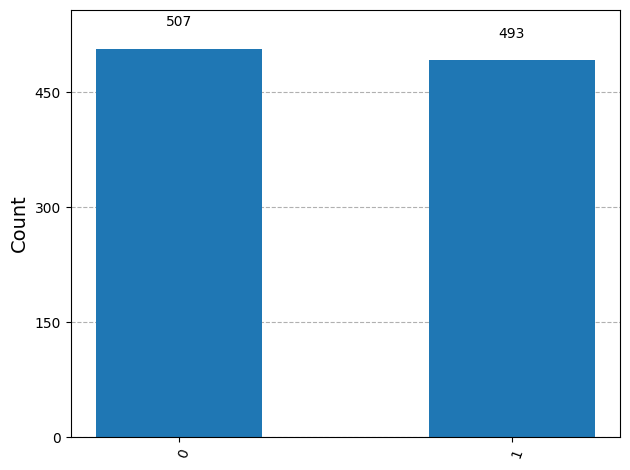

In [62]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
qc = QuantumCircuit(1,1) #1 qubit and 1 classical bit for observation
qc.h(0) #Create superposition equally
qc.measure(0,0) # Measures and collapses superposition

sim = AerSimulator() # Creates the simulator object
job = sim.run(qc, shots =1000)
counts = job.result().get_counts()
plot_histogram(counts)



### Section 3.4 — Tensor Products

Tensor products are how you combine multiple qubits into a joint system. |0⟩ ⊗ |1⟩ = |01⟩. For gates, tensor products let you apply different gates to different qubits simultaneously. H ⊗ I means "apply H to qubit 0 and do nothing to qubit 1."
The dimension explosion: m qubits ⊗ n qubits = 2^(m+n) dimensional space. 2 qubits → 4D, 3 qubits → 8D, 10 qubits → 1024D. This is the computational power.

In [63]:
import numpy as np
zero = np.array([1,0])
one = np.array([0,1])

print(np.kron(zero,one)) #Kronecker product or tensor product for matrices

[0 1 0 0]


### Section 3.4.3 — Entanglement

Step by step what happens:

Start: both qubits = 0
→ state = |00⟩

Put Hadamard on first qubit only

→ first qubit becomes (0 + 1)/√2

→ by Kronecker, whole state becomes: (|00⟩ + |10⟩)/√2

(Because in quantum mechanics, when you have multiple qubits, the total state is always described by one single joint vector (not two separate vectors)
= (1/√2) × |0⟩ ⊗ |0⟩   +   (1/√2) × |1⟩ ⊗ |0⟩
= (1/√2) |00⟩   +   (1/√2) |10⟩
= (|00⟩ + |10⟩)/√2)
Do CNOT (control = first qubit, target = second qubit)

CNOT rule: “if first qubit is 1 → flip second qubit”

So it changes:
|00⟩ stays |00⟩ (because first is 0 → no flip)
|10⟩ becomes |11⟩ (because first is 1 → flip second from 0 to 1)
Result: (|00⟩ + |11⟩)/√2

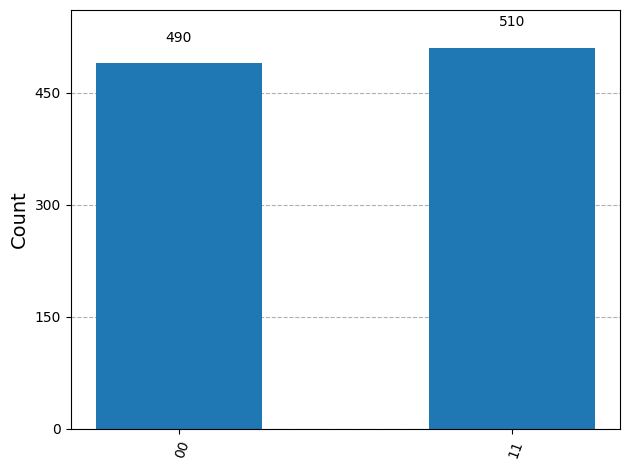

In [64]:
#Bell state - (00 + 11)/ sqrt 2
qc = QuantumCircuit(2,2)
qc.h(0)
qc.cx(0,1)
qc.measure([0,1],[0,1])
job = sim.run(qc, shots = 1000)
counts = job.result().get_counts()
plot_histogram(counts)

### Section 4 — Deutsch-Jozsa Algorithm

The problem: given a black-box function f that is either constant (always outputs 0 or always 1) or balanced (outputs 0 for half inputs, 1 for other half), determine which it is. Classically you need up to 2^(n-1)+1 queries. Quantum: exactly 1 query. Exponential speedup.

Start with n data qubits in |0⟩ and 1 extra "helper" qubit in |1⟩

Put Hadamard on every qubit → creates superposition over all possible inputs at once

→ the n qubits are now trying every input 00,01,10,11 simultaneously
Call the secret function (oracle) once

→ instead of getting 0/1 normally, it flips the phase (multiplies by -1) whenever f(x)=1

Put Hadamard again on the first n qubits

→ this makes all the different paths interfere (like waves)
Measure the first n qubits

In [68]:
def deutsch_jozsa(oracle_type='constant'):
   #^Chooses which secret function f to simulate, default is constant
   n=2
   qc = QuantumCircuit(n+1,n) #qubits 0 & 1 → input register (x); qubit 2 → helper that carries phase info
   qc.x(n) #Apply X-Gate to helper qubit, changing it to 1; later the oracle will flip the phase to -1 if f(x) = 1; But we want that phase to go back to the input register (not stay on helper).
           #Starting helper in |1⟩ and then Hadamard → puts it in |−⟩ = (|0⟩ − |1⟩)/√2. |−⟩ is an eigenstate of Z with eigenvalue −1 → any phase flip on helper becomes a kickback phase on the control qubits.
   qc.h(range(n+1)) #H to all qubits

   if oracle_type == 'balanced':
    qc.cx(0,n)

   qc.h(range(n))
   qc.measure(range(n),range(n)) #measure first n qubits
   return qc

for oracle in ['constant','balanced']:
    qc=deutsch_jozsa(oracle)
    job=AerSimulator().run(qc,shots=1000)
    print(f"{oracle}:{job.result().get_counts()}")





constant:{'00': 1000}
balanced:{'01': 1000}
